In [4]:
import matplotlib.pyplot as plt
import numpy as np
import math
import numpy as np 
import pandas as pd 
import os
import zipfile


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

os.makedirs("/kaggle/working/img/", exist_ok=True)


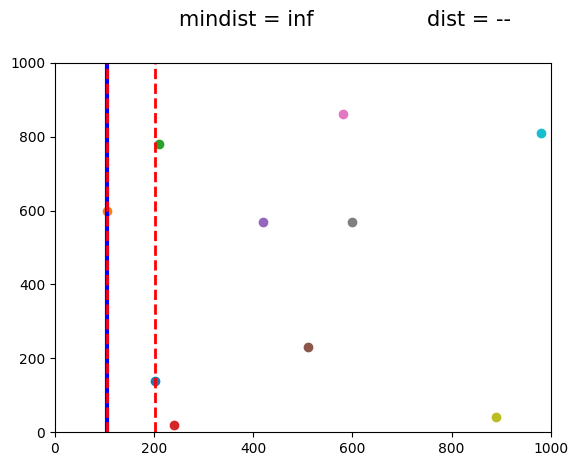

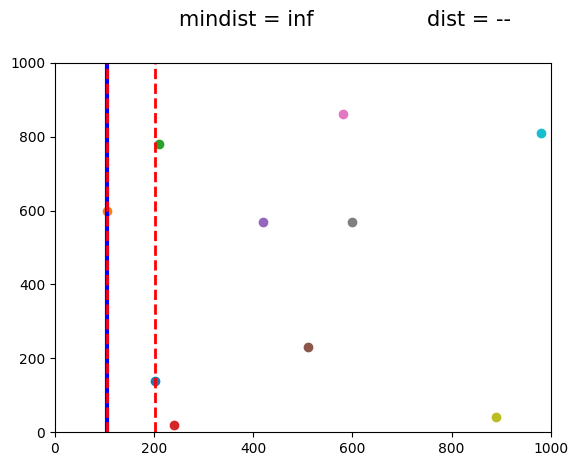

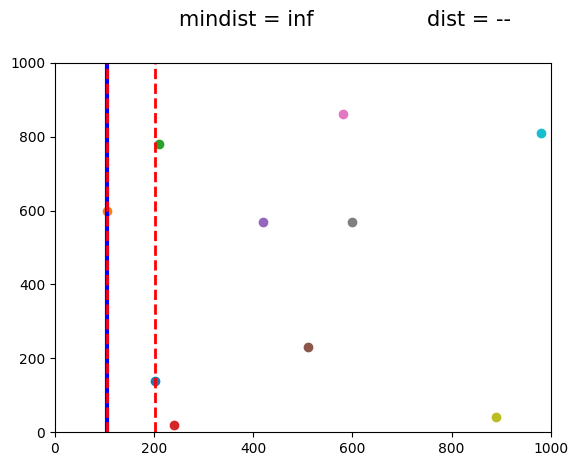

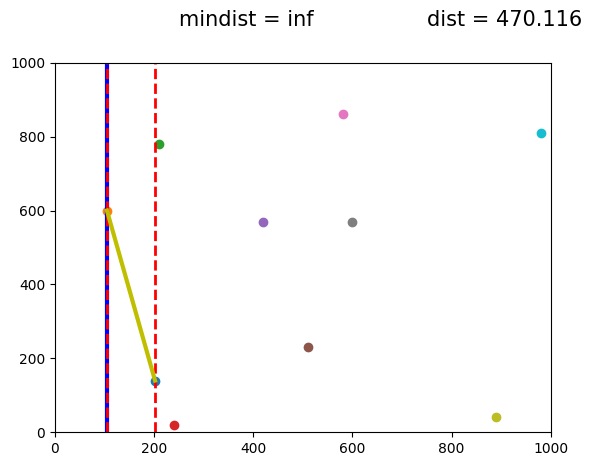

最近点对信息：
p1: (105, 600)
p2: (202, 140)
mindist: 470.1159431459435


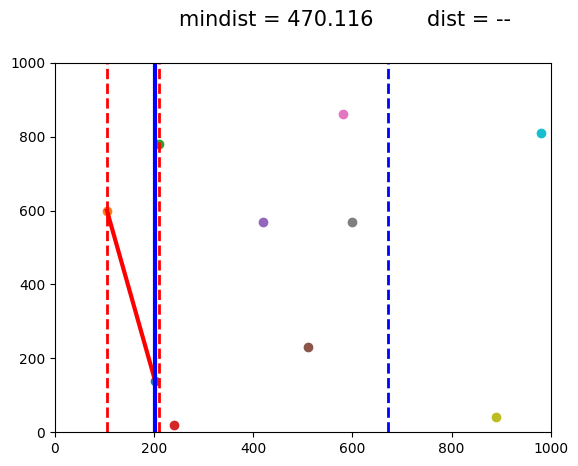

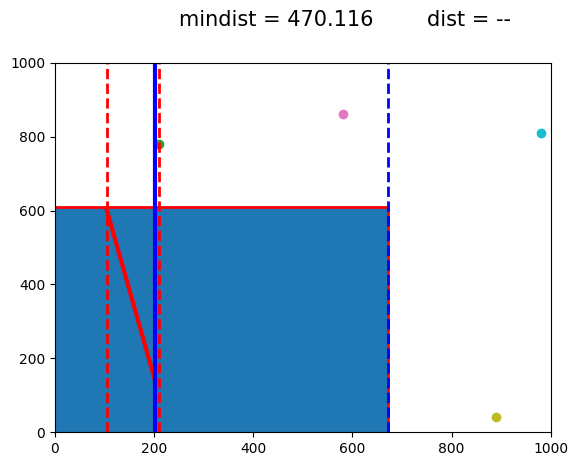

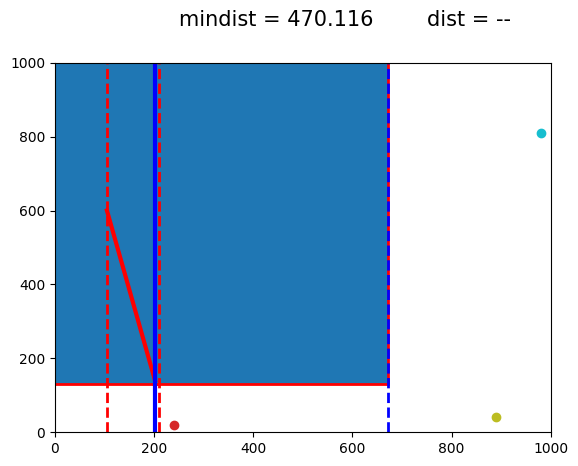

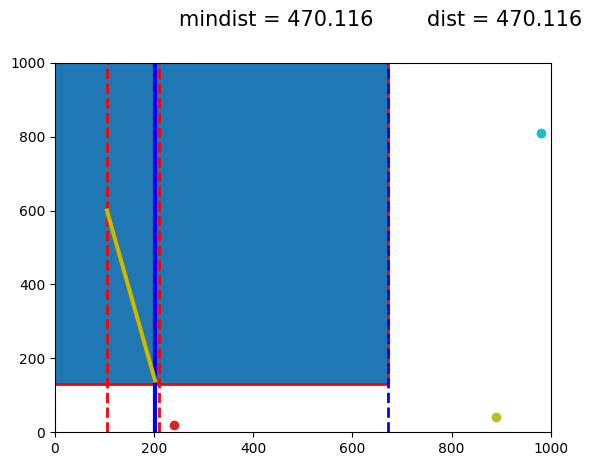

最近点对信息：
p1: (105, 600)
p2: (202, 140)
mindist: 470.1159431459435


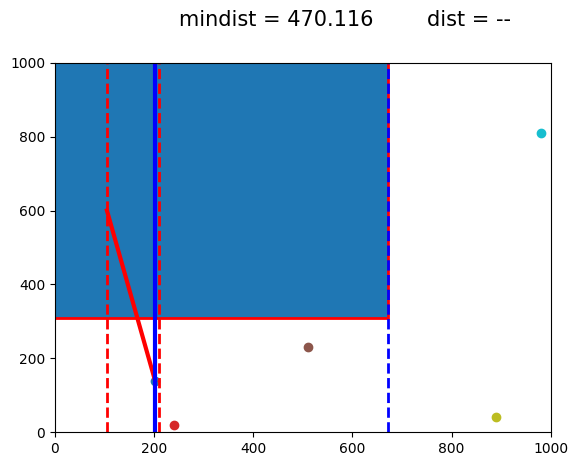

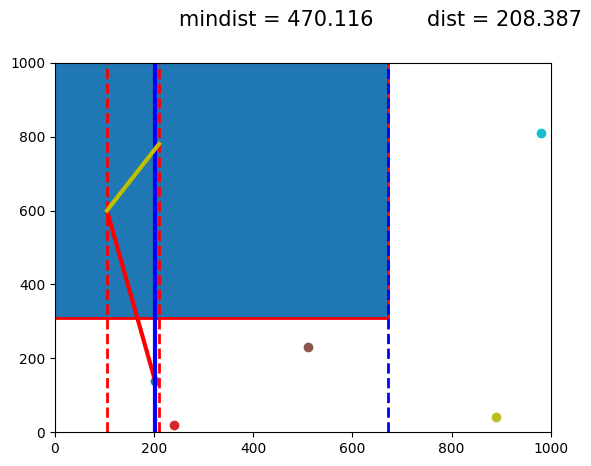

最近点对信息：
p1: (210, 780)
p2: (105, 600)
mindist: 208.38665984174708


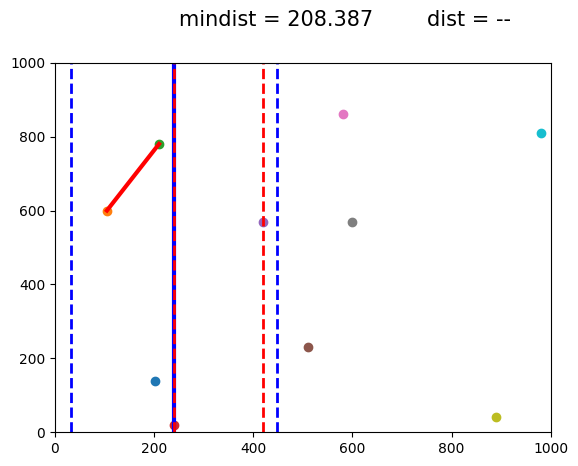

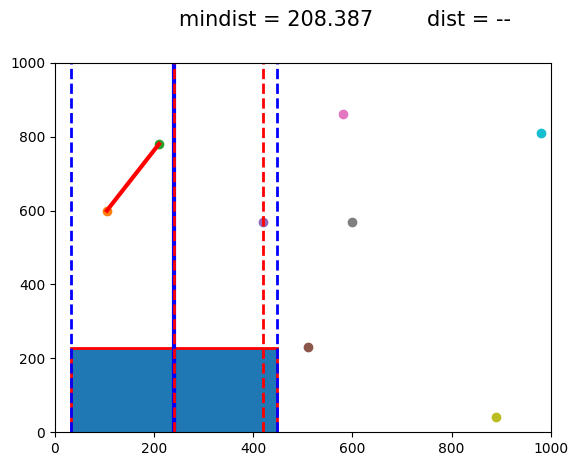

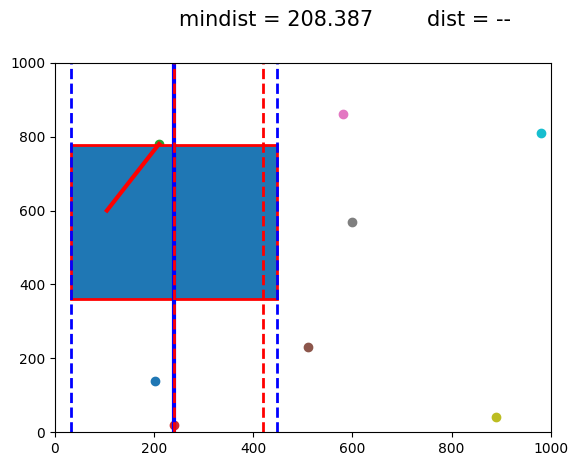

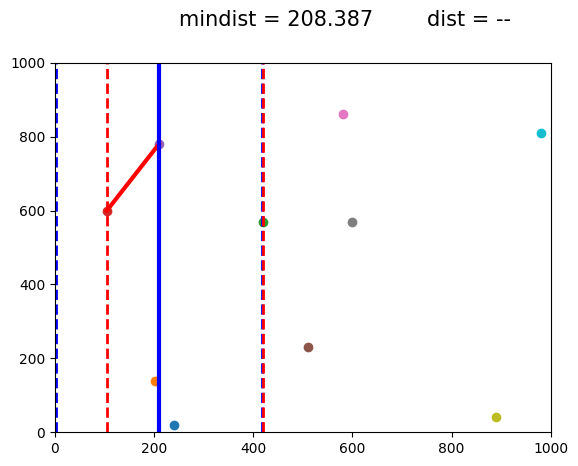

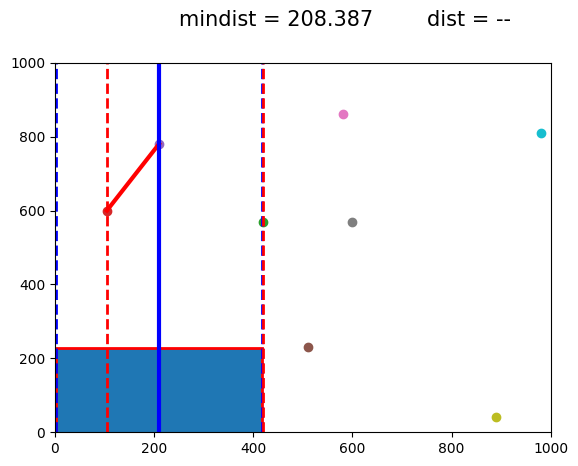

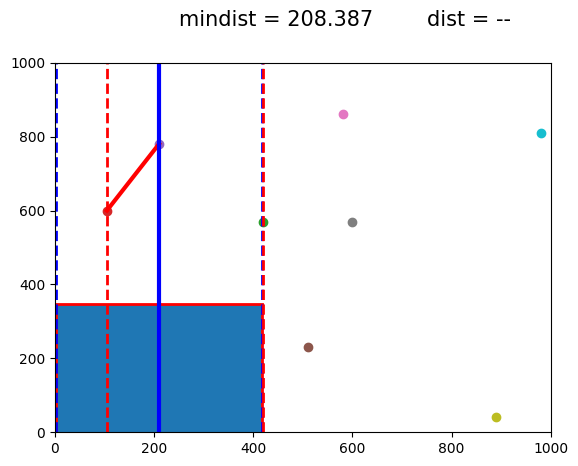

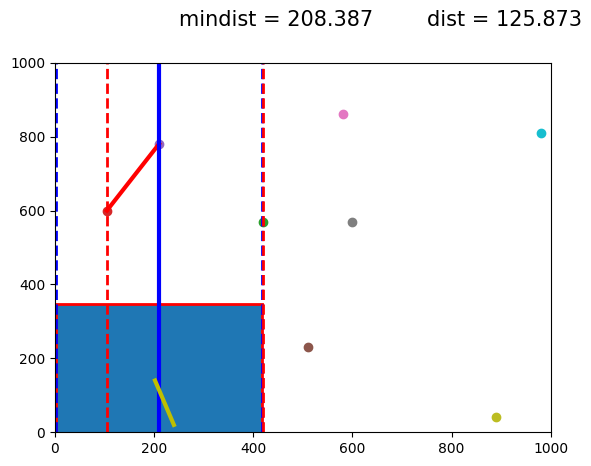

最近点对信息：
p1: (202, 140)
p2: (240, 20)
mindist: 125.8729518204765


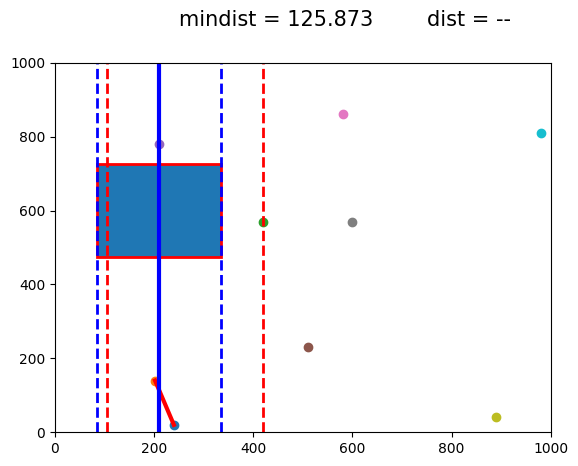

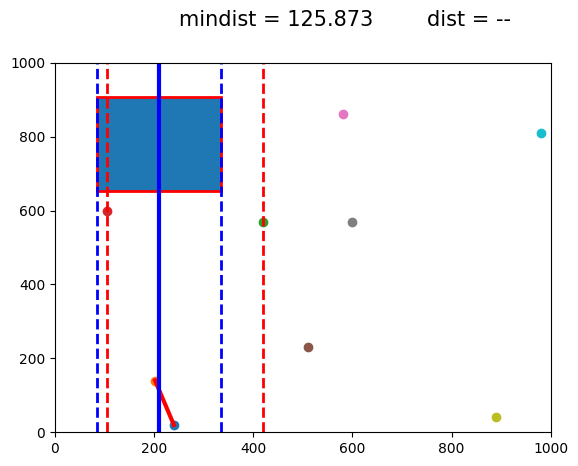

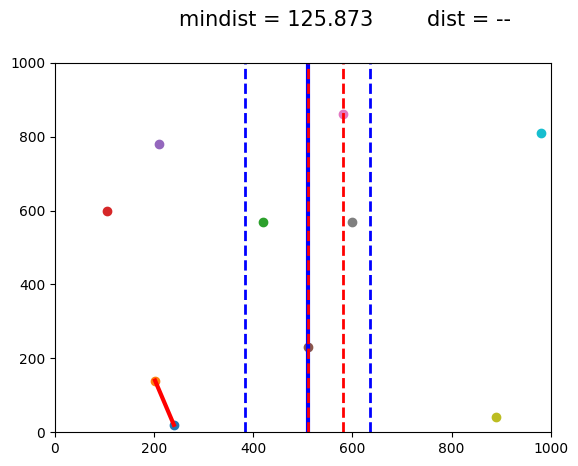

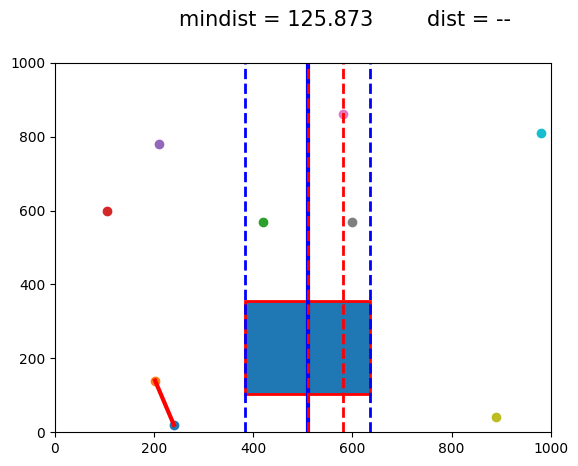

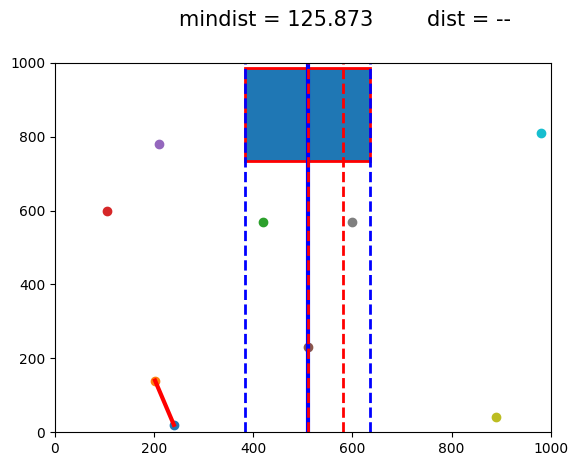

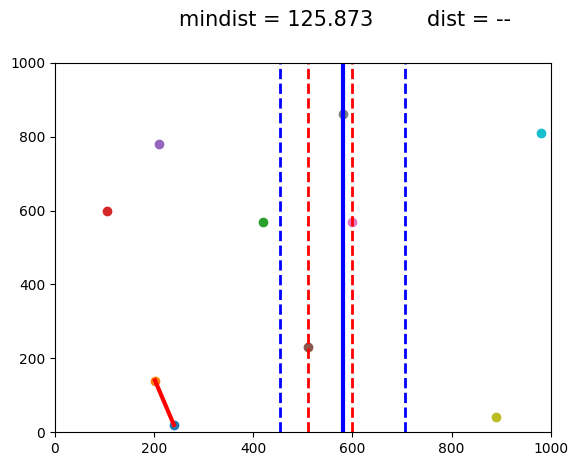

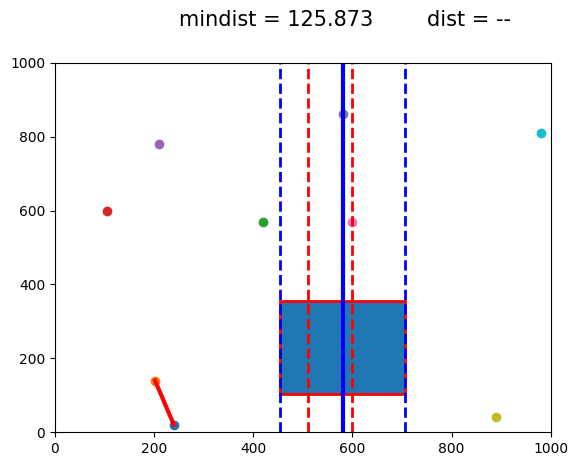

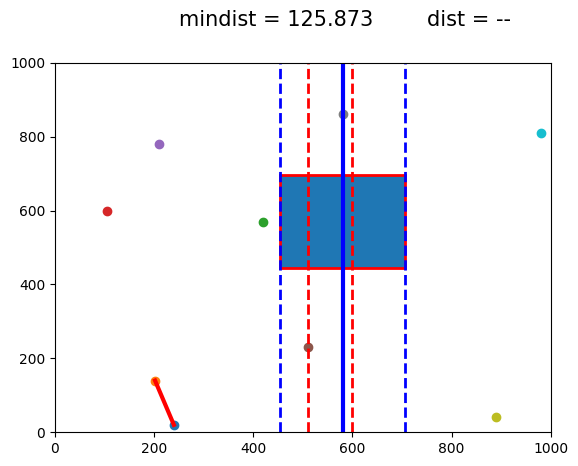

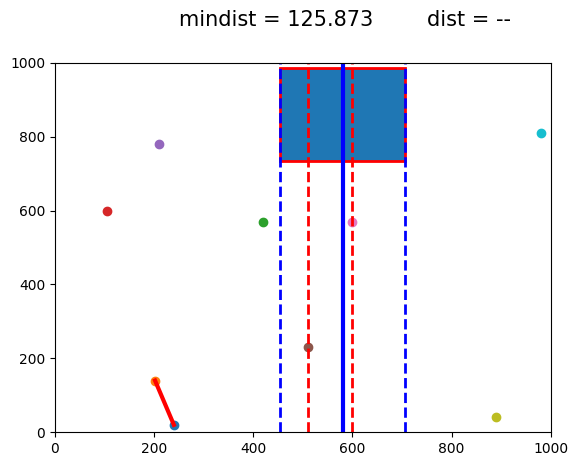

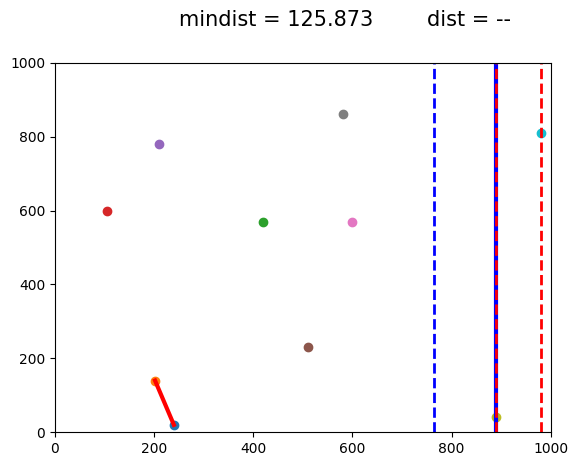

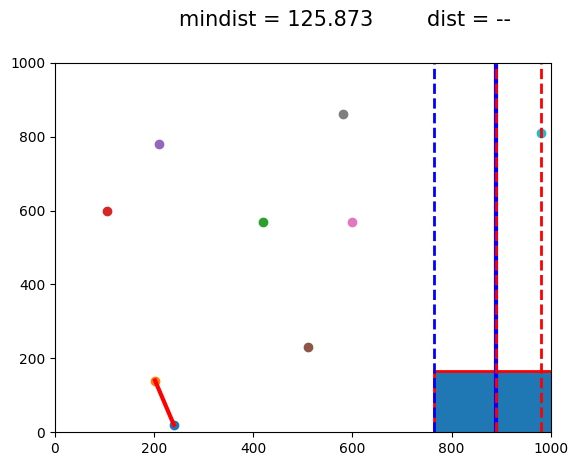

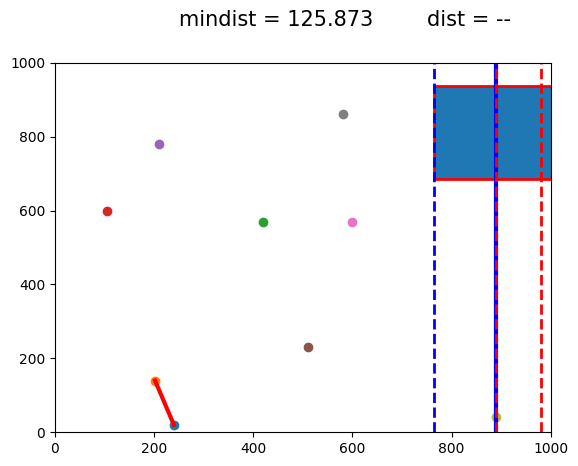

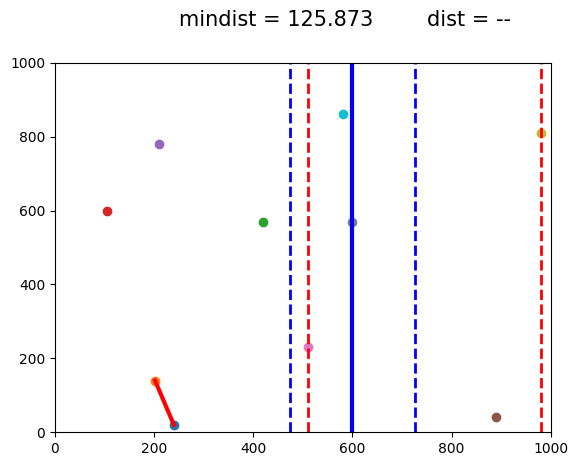

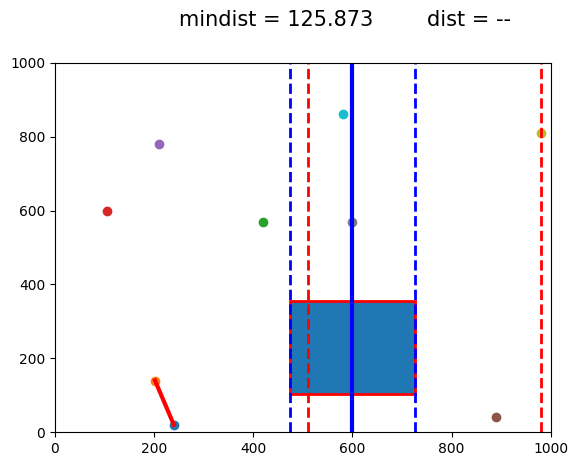

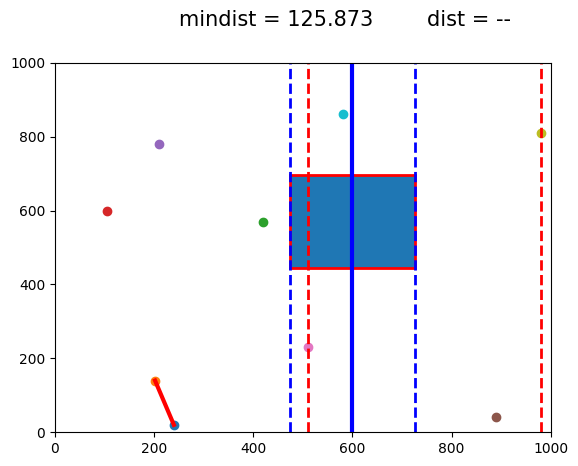

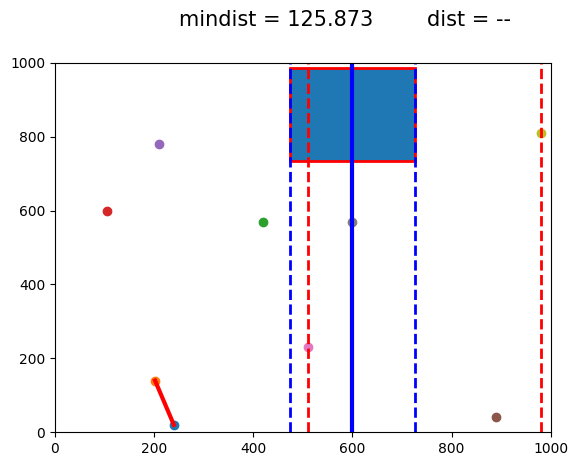

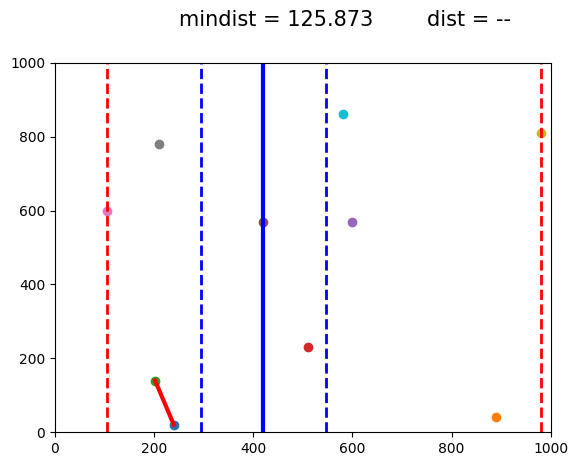

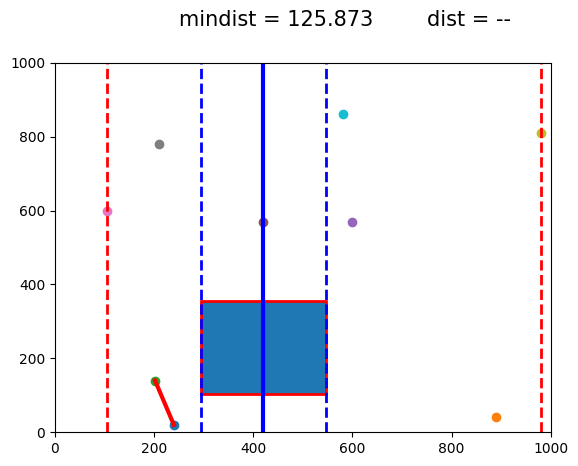

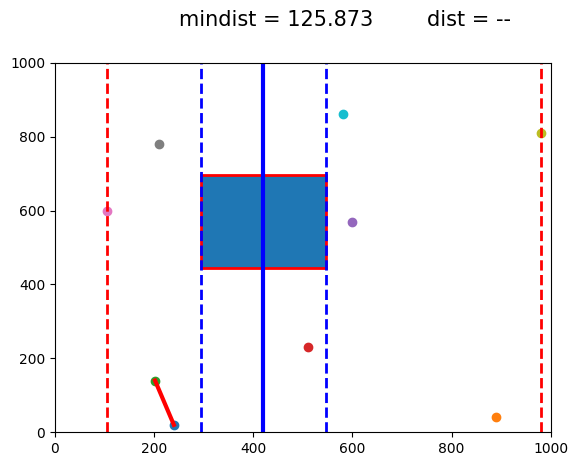

p1: 
202 140    8
p2: 
240 20    9
mindist: 125.873


In [6]:
# ----------------- 数据准备和基本计算 ----------------- #
MAX_POINTS = 10
MAX_COORD = 1000
INFINITY = float('inf')
num_points=MAX_POINTS
class Point:
    def __init__(self, x=0, y=0, id=0):
        self.x = x
        self.y = y
        self.id = id

point_coords = [
    (105, 600), (980, 810), (600, 570), (580, 860), (210, 780),
    (510, 230), (420, 570), (890, 40), (202, 140), (240, 20)
]

points = [Point(x=coord[0], y=coord[1], id=i) for i, coord in enumerate(point_coords)]
min_dist = INFINITY
closest_pair_indices = (-1, -1)
closest_pair_points = [Point(), Point()]

def initialize():
    global min_dist
    min_dist = INFINITY

def calculate_distance(p1, p2):
    return math.hypot(p1.x - p2.x, p1.y - p2.y)

def update_closest_pair(p1, p2):
    global min_dist, closest_pair_indices, closest_pair_points
    dist = calculate_distance(p1, p2)
    if dist < min_dist:
        min_dist = dist
        closest_pair_indices = (p1.id, p2.id)
        closest_pair_points[0] = p1
        closest_pair_points[1] = p2
    print_closest_pair_info()

def print_closest_pair_info():
    p1, p2 = closest_pair_points
    print("最近点对信息：")
    print(f"p1: ({p1.x}, {p1.y})")
    print(f"p2: ({p2.x}, {p2.y})")
    print(f"mindist: {min_dist}")

# ----------------- 图形化展示 ----------------- #
img_counter = 0

def show_plot(mid, left, right, dist):
    global MAX_COORD
    plt.ion()
    plt.clf()
    plt.xlim(0, MAX_COORD)
    plt.ylim(0, MAX_COORD)
    for point in points:
        plt.scatter(point.x, point.y)
    if closest_pair_indices[0] != -1:
        plt.plot([closest_pair_points[0].x, closest_pair_points[1].x], 
                 [closest_pair_points[0].y, closest_pair_points[1].y], 
                 c="r", lw=3)
    plt.axvline(x=mid, c="b", lw=3)
    plt.axvline(x=mid - min_dist, ls='--', c='b', lw=2)
    plt.axvline(x=left, ls='--', c='r', lw=2)
    plt.axvline(x=mid + min_dist, ls='--', c='b', lw=2)
    plt.axvline(x=right, ls='--', c='r', lw=2)
    plt.text(MAX_COORD * 0.25, MAX_COORD * 1.1, f"mindist = {min_dist:.3f}", fontsize=15)
    # 修改这里的描述
    plt.text(MAX_COORD * 0.75, MAX_COORD * 1.1, f"dist = {'--' if dist == 0 else f'{dist:.3f}'}", fontsize=15)

def show_image(mid, left, right, type, point):
    show_plot(mid, left, right, 0)
    if type == 1:
        show_rectangle(point, mid)
    global img_counter
    img_counter += 1
    plt.savefig(f"img/{img_counter}.png")
    plt.pause(0.5)

def show_current_pair(mid, left, right, p1, p2, dist):
    show_plot(mid, left, right, dist)
    show_rectangle(p1, mid)
    plt.plot([p1.x, p2.x], [p1.y, p2.y], c="y", lw=3)
    global img_counter
    img_counter += 1
    plt.savefig(f"/kaggle/working/img/{img_counter}.png")
    plt.pause(0.5)

def draw_rectangle(x, y, w, h):
    plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='r', linewidth=2))

def show_rectangle(point, mid):
    left = mid - min_dist
    draw_rectangle(left, point.y - min_dist, 2 * min_dist, 2 * min_dist)
# ----------------- 图形化展示 ----------------- #

# ----------------- 分治算法 nlogn ----------------- #
def merge_sort_by_y(points, left, mid, right):
    temp_points = [Point() for _ in range(left, right + 1)]
    li, ri = left, mid + 1
    idx = 0
    while li <= mid and ri <= right:
        if points[li].y < points[ri].y:
            temp_points[idx] = points[li]
            li += 1
        else:
            temp_points[idx] = points[ri]
            ri += 1
        idx += 1
    while li <= mid:
        temp_points[idx] = points[li]
        li += 1
        idx += 1
    while ri <= right:
        temp_points[idx] = points[ri]
        ri += 1
        idx += 1
    points[left:right + 1] = temp_points

def find_closest_pair_recursively(left, right):
    if left == right:
        return
    mid = (left + right) // 2
    mid_x = points[mid].x
    left_x, right_x = points[left].x, points[right].x
    find_closest_pair_recursively(left, mid)
    find_closest_pair_recursively(mid + 1, right)
    merge_sort_by_y(points, left, mid, right)
    show_image(mid_x, left_x, right_x, 0, 0)
    temp_points = []
    for i in range(left, right + 1):
        if abs(points[i].x - mid_x) < min_dist:
            show_image(mid_x, left_x, right_x, 1, points[i])
            for j in range(len(temp_points) - 1, -1, -1):
                if points[i].y - temp_points[j].y >= min_dist:
                    break
                show_current_pair(mid_x, left_x, right_x, points[i], temp_points[j], calculate_distance(points[i], temp_points[j]))
                update_closest_pair(points[i], temp_points[j])
            temp_points.append(points[i])

def find_closest_pair():
    points.sort(key=lambda p: p.x)  # 按x轴排序
    find_closest_pair_recursively(0, num_points - 1)
# ----------------- 分治算法 nlogn ----------------- #

# ----------------- 结果测试与检验 ----------------- #
def print_point(index):
    print(f"{points[index].x} {points[index].y}    {points[index].id}")

def print_results():
    points.sort(key=lambda p: p.id)
    print("p1: ")
    print_point(closest_pair_indices[0])
    print("p2: ")
    print_point(closest_pair_indices[1])
    print(f"mindist: {min_dist:.3f}")
# ----------------- 结果测试与检验 ----------------- #

initialize()
find_closest_pair()
print_results()

In [8]:
#“打包图片”#
# 指定要打包的文件夹路径
folder_to_zip = '/kaggle/working/img/'

# 指定要创建的zip文件路径
zip_file_path = '/kaggle/working/images.zip'

# 创建一个zip文件对象
with zipfile.ZipFile(zip_file_path, 'w') as zipf:
    # 遍历文件夹中的所有文件，并将它们添加到zip文件中
    for root, dirs, files in os.walk(folder_to_zip):
        for file in files:
            file_path = os.path.join(root, file)
            # 将文件添加到zip文件中
            zipf.write(file_path, os.path.relpath(file_path, folder_to_zip))

print(f'成功创建zip文件：{zip_file_path}')

成功创建zip文件：/kaggle/working/images.zip


In [9]:
!pip install opencv-python


In [10]:
# 把打包的图片图形化 #
import cv2
import os

# 图像所在的文件夹路径
img_folder = '/kaggle/working/img'  # 确保图像文件上传到此目录
output_video = '/kaggle/working/output_video.avi'  # 输出的视频路径

# 设置视频的帧率
fps =2  # 可根据需求调整

# 获取文件夹内所有图像文件，并按顺序排序
img_files = [f for f in os.listdir(img_folder) if f.endswith('.png')]
img_files.sort(key=lambda x: int(x.split('.')[0]))  # 按文件名排序

# 读取第一张图像来获取尺寸
first_img = cv2.imread(os.path.join(img_folder, img_files[0]))
height, width, _ = first_img.shape

# 定义视频的编码方式及输出视频
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # 使用 XVID 编码
video_writer = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# 遍历图像文件并将其写入视频
for img_file in img_files:
    img_path = os.path.join(img_folder, img_file)
    img = cv2.imread(img_path)
    video_writer.write(img)  # 将图像写入视频

# 释放资源
video_writer.release()
print(f"视频已保存为 {output_video}")


视频已保存为 /kaggle/working/output_video.avi


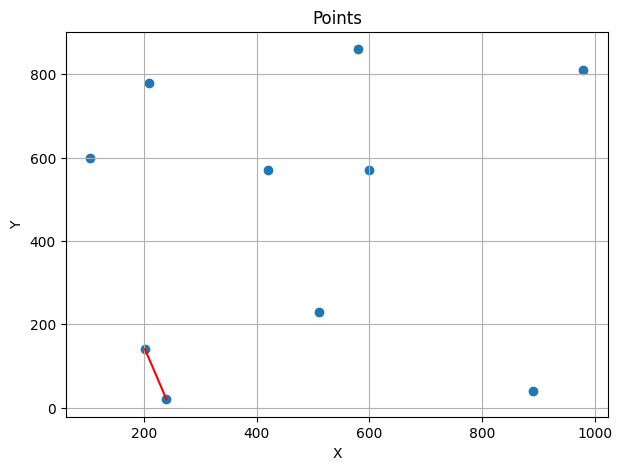

In [15]:
#生成的随机点图像
# 分离 x 和 y 坐标
x, y = zip(*point_coords)

# 创建图形
plt.figure(figsize=(7, 5))
plt.scatter(x, y)

# 给定的点坐标
p1 = (202, 140)  # 第一个点
p2 = (240, 20)   # 第二个点

#绘制图线
plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-')

# 设置图形标题和坐标轴标签
plt.title('Points')
plt.xlabel('X')
plt.ylabel('Y')

# 显示图形
plt.grid(True)
plt.show()